**Convolutional** **Neural** **Network** (**CNN**)


A Convolutional Neural Network (CNN) is a specialized type of
artificial neural network (NN) optimized for processing grid-like data such as images, video, and audio. It uses core layers including convolution, pooling, and fully connected.

Core Layers of a CNN

**Convolutional** **Layer**: Uses small sliding filters (kernels) to scan inputs and create
feature maps that detect local patterns like edges and textures.

**Pooling** **Layer**: Downsamples feature maps to reduce spatial size, memory usage,
and the number of parameters.

**Fully** **Connected** **Layer**: Flattens the final features into a standard neural network
layer to perform high-level classification or regression.

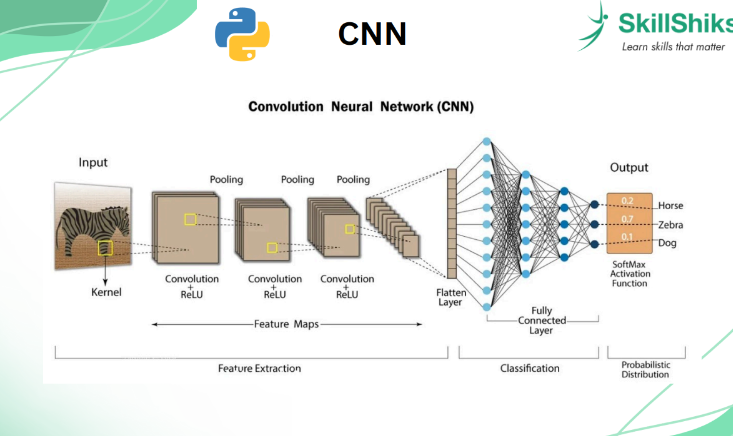

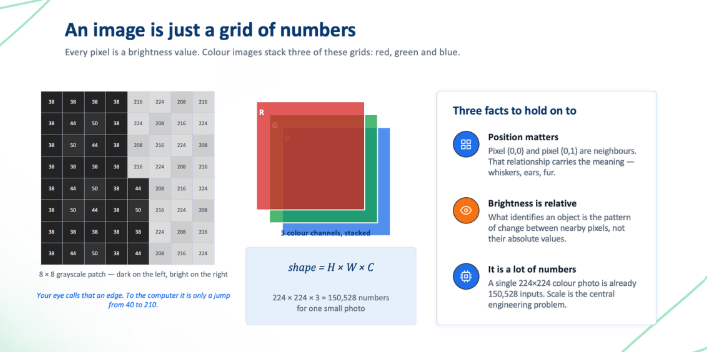

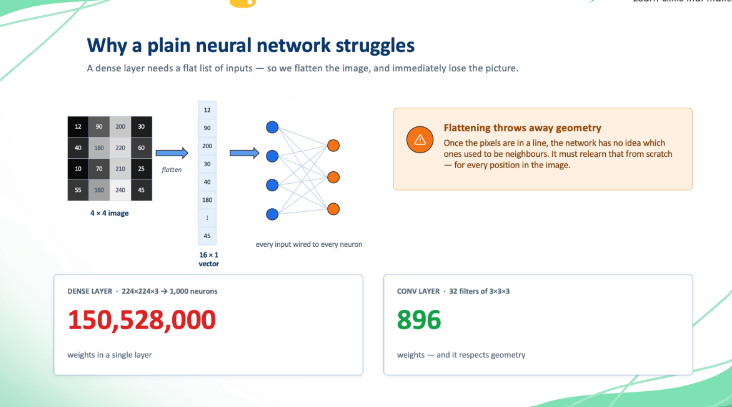

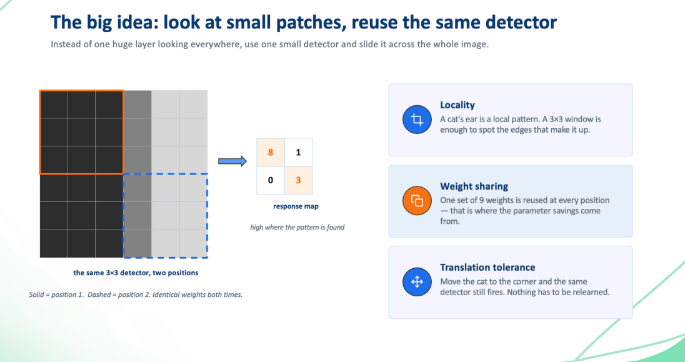

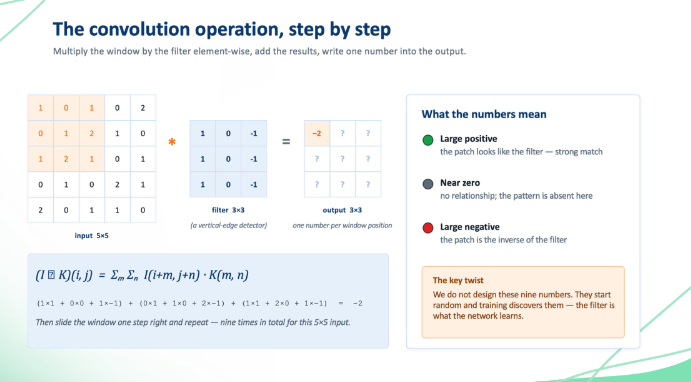

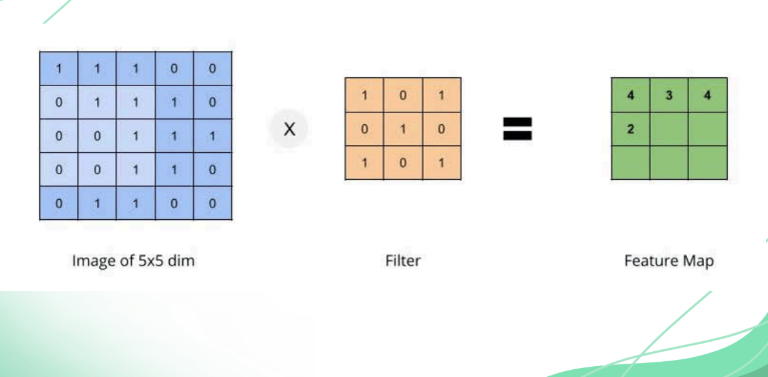

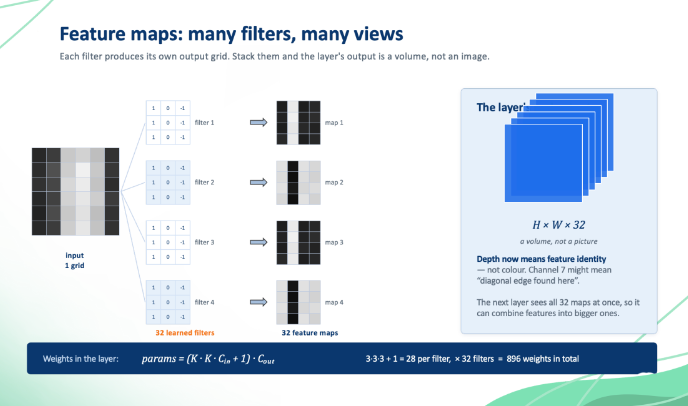

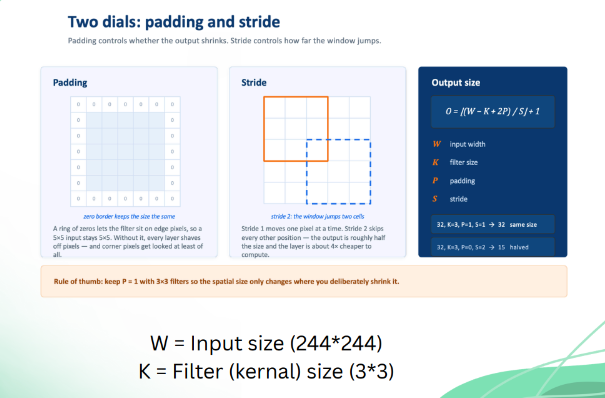

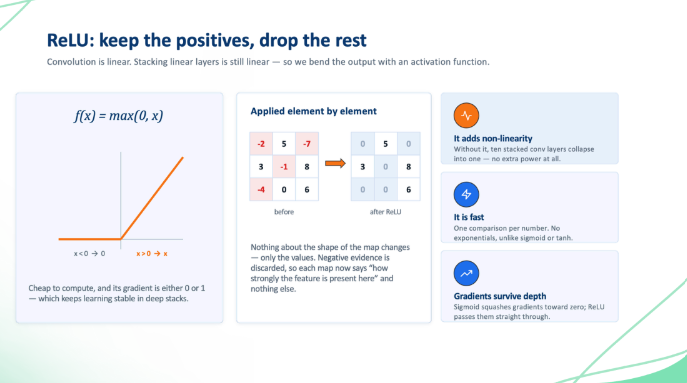

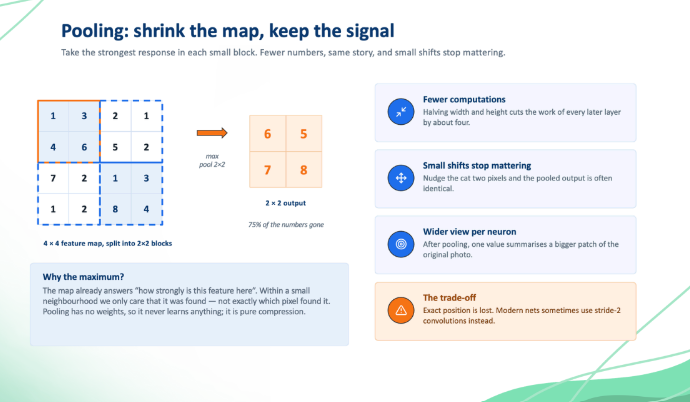

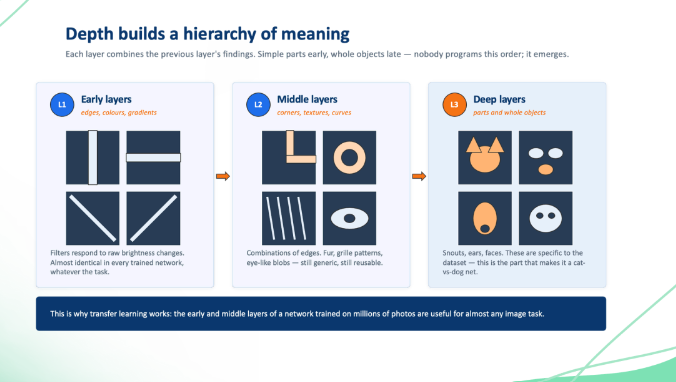

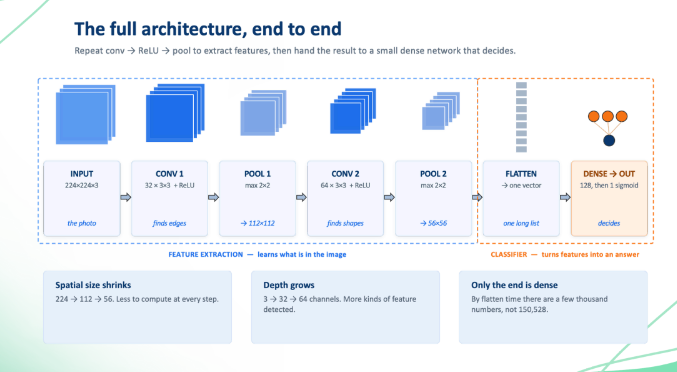

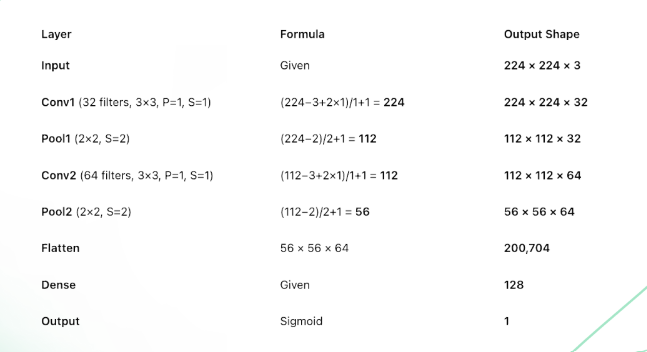

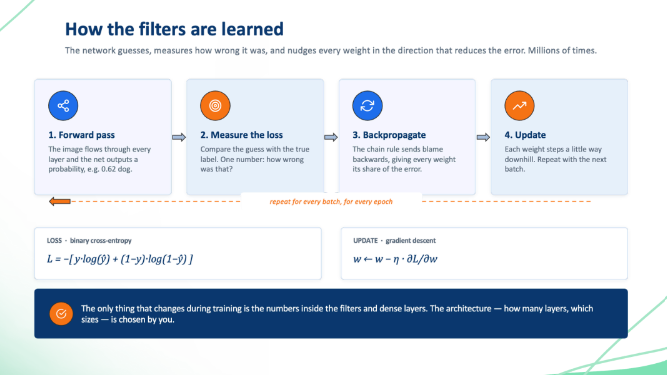

input = convolution =

output size = ((N-F+2P)/S )+ 1

where, N = input size

F = filter(kernel size)

p = padding

S stride


In [1]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [3]:
from tensorflow.keras.datasets import mnist

In [ ]:
# CNN in MNIST Data

In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


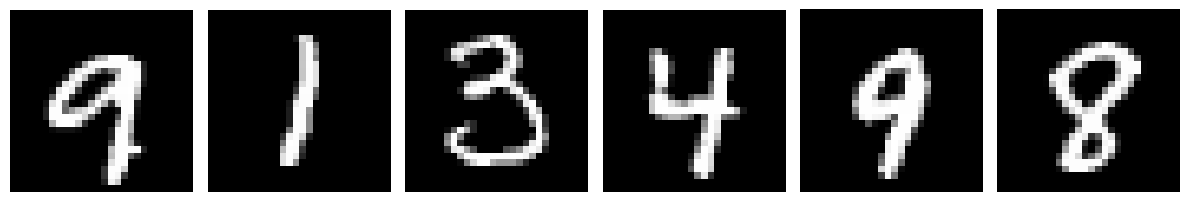

In [5]:
import matplotlib.pyplot as plt
import numpy as np

#select 6 images
indices = np. random. choice(len(X_train), 6, replace=False)
selected_images = [X_train[i] for i in indices]
#create subplots

fig, axes =plt.subplots(1,6, figsize=(12,5))


for ax, img in zip(axes, selected_images):
 ax.imshow(img, cmap='gray')
 ax.axis('off') #turn off axes for a clean look

plt.tight_layout()
plt.show()


In [8]:
# Data processing
X_train = X_train.reshape(*X_train.shape, 1)
X_test = X_test.reshape(*X_test.shape, 1)

X_train = X_train/255
y_train = y_train/255
# Formula: Normalized_Pixel = Pixel/255.0

In [9]:
import_shape = X_train.shape[1:]
num_classes = len(np.unique(y_train))

In [11]:
from tensorflow.keras.datasets import mnist
import numpy as np

# Reload MNIST data to ensure correct initial shape
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape data to include a channel dimension and normalize
# Ensure shape is (num_samples, height, width, channels)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

X_train = X_train / 255.0
X_test = X_test / 255.0

# Recalculate input_shape and num_classes
input_shape = X_train.shape[1:]  # Should now be (28, 28, 1)
num_classes = len(np.unique(y_train))

# Redefine the model with the corrected input_shape
model = Sequential()

model.add(Input(shape=input_shape))

model.add(Conv2D(filters=6, kernel_size=(5,5), strides=(1,1), padding="valid", activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2)) #( 24 -2+0)/2 +1 = 11 + 1 = 12

model.add(Conv2D(filters=16, kernel_size=(5,5), strides=(1,1), padding="valid", activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2))

model.add(Flatten())

model.add(Dense(100, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(50, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

In [12]:
model.summary()

# fully conection (Dense layer)
#  (no of input * no of output) + no of bais

#convolution layer
 # (input filter width * input filter height * Input depth * number of filter) + no of baised
 #5*5*1*6+6 = 156

#  5*5*6*16+16 = 2416


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,832 (132.16 KB)

 Trainable params: 33,832 (132.16 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer="Adam",
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    X_train, y_train, epochs=3, batch_size=64, verbose=1, validation_split=0.2
)

Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - accuracy: 0.9040 - loss: 0.3143 - val_accuracy: 0.9734 - val_loss: 0.0870
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9707 - loss: 0.0985 - val_accuracy: 0.9824 - val_loss: 0.0604
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9764 - loss: 0.0777 - val_accuracy: 0.9852 - val_loss: 0.0521


In [15]:
import pandas as pd
df = pd.DataFrame(history.history)

<Axes: >

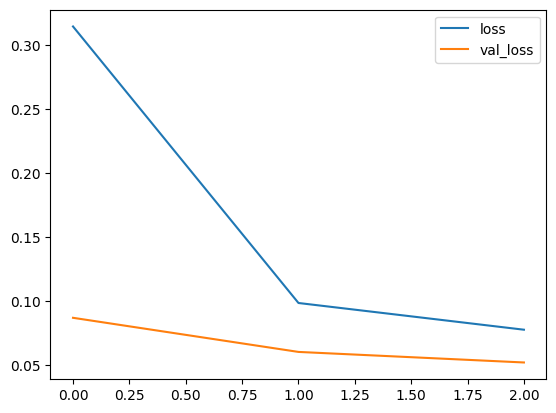

In [16]:
df[['loss', 'val_loss']].plot.line()

In [17]:
pred = np.argmax(model.predict(X_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [18]:
from sklearn.metrics import confusion_matrix

In [19]:
confusion_matrix(y_test, pred)

array([[ 973,    1,    0,    0,    0,    0,    5,    1,    0,    0],
       [   0, 1128,    2,    2,    0,    0,    1,    2,    0,    0],
       [   1,    1, 1025,    1,    0,    0,    1,    2,    1,    0],
       [   0,    0,    5,  993,    0,    3,    0,    7,    2,    0],
       [   0,    0,    0,    0,  979,    0,    1,    0,    0,    2],
       [   2,    0,    1,    5,    0,  879,    2,    1,    1,    1],
       [   5,    2,    1,    0,    3,    2,  943,    0,    2,    0],
       [   2,    2,    9,    1,    0,    1,    0, 1011,    1,    1],
       [   7,    0,    6,    5,    2,    0,    1,    2,  949,    2],
       [   3,    5,    1,    1,   14,    1,    0,   11,    4,  969]])